# End-to-End Sales Forecasting & Demand Intelligence System

### AI Internship - Week 3 & Week 4

**Prepared by:** Abdur Rahman M

---

## Business Problem

Retail businesses must accurately predict future product demand to maintain the right inventory levels. Overstocking increases storage costs and ties up capital, while understocking results in lost sales and dissatisfied customers.

This project develops an end-to-end demand intelligence system that forecasts future sales, identifies unusual sales behavior, segments products based on demand patterns, and presents insights through an interactive dashboard to support data-driven business decisions.

## Project Objectives

The objectives of this project are to:

- Analyze historical sales data and identify long-term trends and seasonal patterns.
- Build and compare three forecasting models (SARIMA, Prophet, and XGBoost).
- Predict future sales for the next three months.
- Detect unusual sales spikes and declines using anomaly detection techniques.
- Segment products based on demand characteristics using clustering.
- Develop an interactive Streamlit dashboard for business users.
- Present actionable recommendations for inventory planning and demand forecasting.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)

import warnings
warnings.filterwarnings("ignore")

# Task 1 – Data Loading & Deep Exploration

The first step is to understand the dataset by examining its structure, checking for data quality issues, and extracting useful time-based features. Since this is a time-series forecasting project, correctly parsing date columns is essential for all subsequent analyses.

In [ ]:
# Load the dataset
df = pd.read_csv(
    "/content/drive/MyDrive/train.csv"
)


# Convert date columns
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

# Display the first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
display(pd.DataFrame(df.columns, columns=["Column Name"]))

print("\nDataset Information:")
df.info()

df.describe(include="all").T

Dataset Shape: (9800, 18)

Columns:


,Column Name
0,Row ID
1,Order ID
2,Order Date
3,Ship Date
4,Ship Mode
5,Customer ID
6,Customer Name
7,Segment
8,Country
9,City



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15 

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,9800.0,NaN,NaN,NaN,4900.5,1.0,2450.75,4900.5,7350.25,9800.0,2829.160653
Order ID,9800,4922,CA-2018-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9800,NaN,NaN,NaN,2017-05-01 05:13:51.673469440,2015-01-03 00:00:00,2016-05-24 00:00:00,2017-06-26 00:00:00,2018-05-15 00:00:00,2018-12-30 00:00:00,NaN
Ship Date,9800,NaN,NaN,NaN,2017-05-05 04:17:52.653061120,2015-01-07 00:00:00,2016-05-27 18:00:00,2017-06-29 00:00:00,2018-05-19 00:00:00,2019-01-05 00:00:00,NaN
Ship Mode,9800,4,Standard Class,5859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9800,793,WB-21850,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9800,793,William Brown,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9800,3,Consumer,5101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9800,1,United States,9800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9800,529,New York City,891,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Missing Values

In [ ]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing

,Missing Values,Percentage
Row ID,0,0.000000
Order ID,0,0.000000
Order Date,0,0.000000
Ship Date,0,0.000000
Ship Mode,0,0.000000
Customer ID,0,0.000000
Customer Name,0,0.000000
Segment,0,0.000000
Country,0,0.000000
City,0,0.000000


#### Duplicate Rows

In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


#### Data Type Summary

In [ ]:
dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str)
})

dtype_summary

,Column,Data Type
Row ID,Row ID,int64
Order ID,Order ID,object
Order Date,Order Date,datetime64[ns]
Ship Date,Ship Date,datetime64[ns]
Ship Mode,Ship Mode,object
Customer ID,Customer ID,object
Customer Name,Customer Name,object
Segment,Segment,object
Country,Country,object
City,City,object


#### Feature Engineering

In [ ]:
# Copy dataframe
sales_df = df.copy()

# Year
sales_df["Year"] = sales_df["Order Date"].dt.year

# Month Number
sales_df["Month"] = sales_df["Order Date"].dt.month

# Month Name
sales_df["Month_Name"] = sales_df["Order Date"].dt.month_name()

# Week Number
sales_df["Week"] = sales_df["Order Date"].dt.isocalendar().week.astype(int)

# Day Name
sales_df["DayOfWeek"] = sales_df["Order Date"].dt.day_name()

# Quarter
sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

# Shipping Time
sales_df["Shipping_Days"] = (
    sales_df["Ship Date"] -
    sales_df["Order Date"]
).dt.days

In [ ]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

sales_df["Season"] = sales_df["Month"].apply(get_season)

## Business Question 1: Which Product Category Generates the Highest Revenue?

,Category,Sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


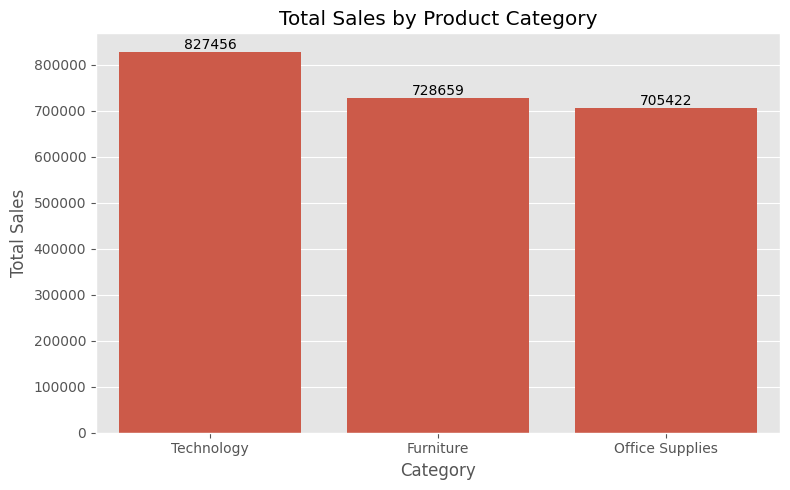

In [ ]:
category_sales = (
    sales_df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(category_sales)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=category_sales,
    x="Category",
    y="Sales"
)

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/charts/category_sales.png", dpi=300)
plt.show()

#### Answer

Technology is the highest revenue-generating category with total sales of **827,455.87**, contributing significantly more revenue than Furniture and Office Supplies. This suggests that technology products should receive higher forecasting priority, inventory allocation, and marketing focus because demand fluctuations in this category have the greatest financial impact.

## Business Question 2: Which region has the most consistent sales growth over 4 years?


,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


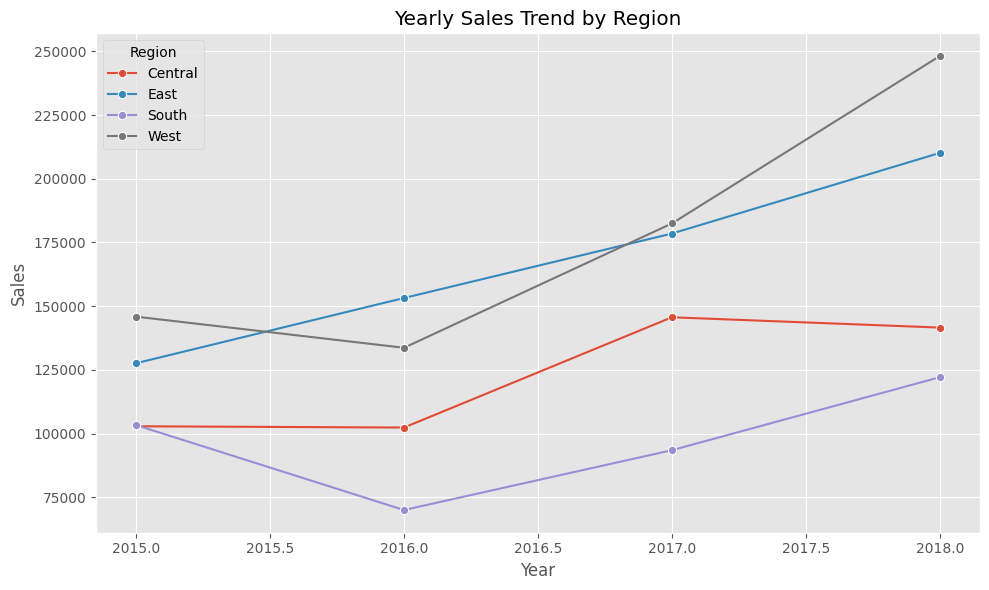

In [ ]:
region_year_sales = (
    sales_df.groupby(["Year","Region"])["Sales"]
    .sum()
    .reset_index()
)

display(region_year_sales.head())

plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales Trend by Region")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/charts/region_growth.png", dpi=300)

plt.show()

#### Answer

The **West region** demonstrates the strongest long-term sales growth, particularly between 2016 and 2018, making it the fastest-growing market in the dataset. The **East region** also exhibits stable year-over-year growth, while the Central and South regions experience slower or more inconsistent performance. These findings suggest that inventory expansion efforts should prioritize the West region.

## Business Question 3: What is the average time between Order Date and Ship Date — and does it vary by region?

,mean,median,min,max
Region,,,,
Central,4.07,4.0,0,7
East,3.91,4.0,0,7
South,3.96,4.0,0,7
West,3.93,4.0,0,7


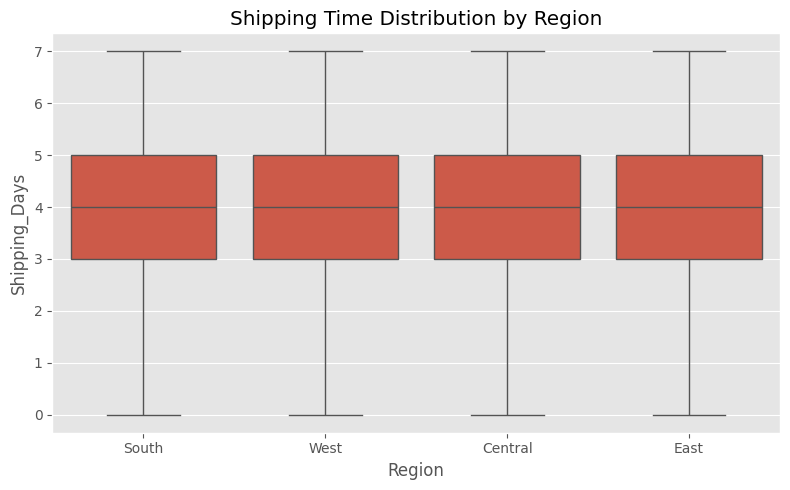

In [ ]:
shipping_summary = (
    sales_df.groupby("Region")["Shipping_Days"]
    .agg(["mean","median","min","max"])
    .round(2)
)

display(shipping_summary)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=sales_df,
    x="Region",
    y="Shipping_Days"
)

plt.title("Shipping Time Distribution by Region")

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/charts/shipping_days.png", dpi=300)

plt.show()

#### Answer

Average shipping time is remarkably consistent across all four regions, ranging between **3.91 and 4.07 days**. This indicates a well-balanced logistics network with no major regional delays. Since shipping performance is uniform, future improvements in customer satisfaction are more likely to come from demand forecasting and inventory optimization rather than changes in delivery operations.

## Business Question 4: Are there months that consistently spike across all years (seasonality)?


,Year,Month_Name,Sales
4,2015,January,14205.707
3,2015,February,4519.892
7,2015,March,55205.797
0,2015,April,27906.855
8,2015,May,23644.303


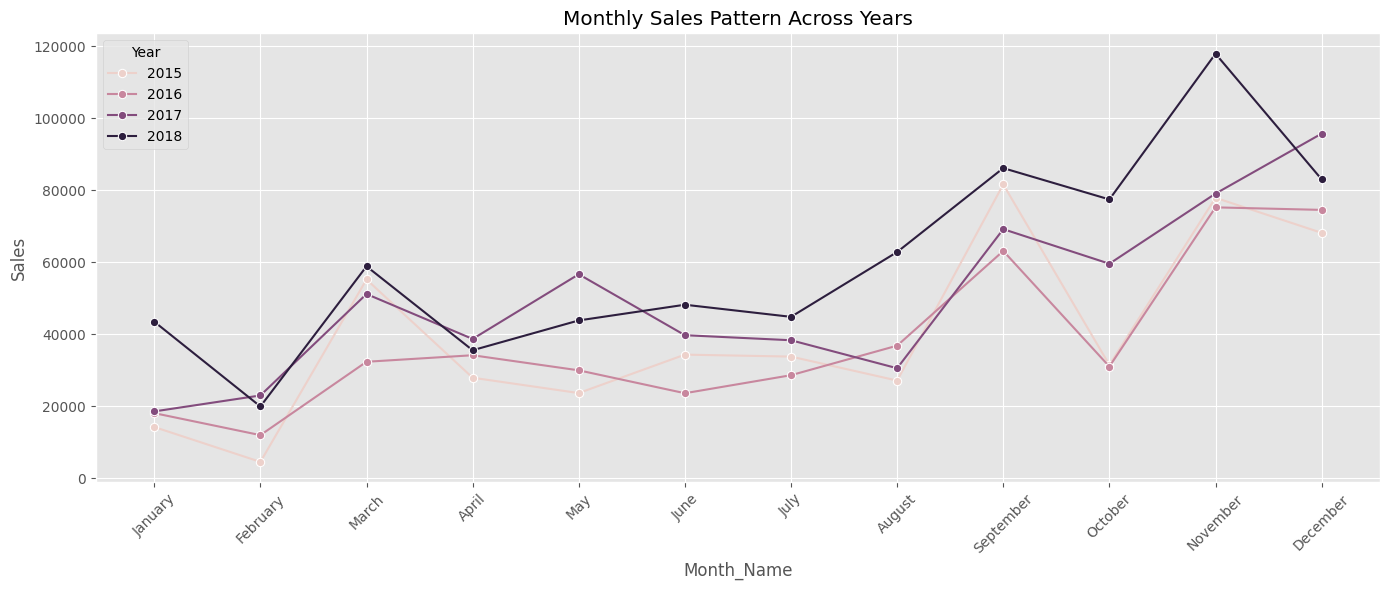

In [ ]:
monthly_sales = (
    sales_df.groupby(["Year","Month_Name"])["Sales"]
    .sum()
    .reset_index()
)

# Keep months in calendar order
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales["Month_Name"] = pd.Categorical(
    monthly_sales["Month_Name"],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values(["Year","Month_Name"])

display(monthly_sales.head())

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_sales,
    x="Month_Name",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Pattern Across Years")

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/charts/monthly_seasonality.png", dpi=300)

plt.show()

#### Answer

Sales exhibit a clear seasonal pattern. Across nearly all years, demand rises significantly during **September through December**, with **November consistently recording the highest sales**. February is generally the weakest month. This recurring trend suggests strong year-end seasonality, likely driven by holiday shopping and promotional events, making seasonal forecasting especially important.

In [ ]:
summary = pd.DataFrame({
    "Metric":[
        "Total Sales",
        "Average Order Value",
        "Number of Orders",
        "Unique Customers",
        "Unique Products"
    ],
    "Value":[
        round(sales_df["Sales"].sum(),2),
        round(sales_df["Sales"].mean(),2),
        sales_df["Order ID"].nunique(),
        sales_df["Customer ID"].nunique(),
        sales_df["Product ID"].nunique()
    ]
})

summary

,Metric,Value
0,Total Sales,2261536.78
1,Average Order Value,230.77
2,Number of Orders,4922.00
3,Unique Customers,793.00
4,Unique Products,1861.00


### Dataset Summary

The dataset contains **4,922 customer orders**, representing **793 unique customers** and **1,861 products**, with total sales exceeding **2.26 million**. The average order value is approximately **230.77**, indicating a diverse retail environment with substantial product variety suitable for demand forecasting and inventory planning.

## Key Business Findings

- Technology is the highest revenue-generating category.
- The West region exhibits the strongest long-term sales growth.
- Average shipping time remains consistent across all regions (approximately 4 days).
- Sales show strong seasonality, with demand peaking during November and December.
- The dataset contains over 2.26 million in sales across 4,922 orders, making it suitable for advanced forecasting and demand analysis.

# Task 2 – Time Series Analysis & Decomposition

## 2.1 Creating Monthly Sales Time Series

Since forecasting models work on chronological observations, daily transaction-level data is aggregated into monthly total sales. Monthly aggregation smooths short-term fluctuations while preserving long-term trends and seasonal patterns.

In [ ]:
monthly_ts = (
    sales_df
    .set_index("Order Date")
    .resample("M")["Sales"]
    .sum()
)

monthly_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


## 2.2 Overall Monthly Sales Trend

The monthly sales trend provides a high-level view of business performance over the four-year period. It helps identify long-term growth patterns and seasonal fluctuations.:

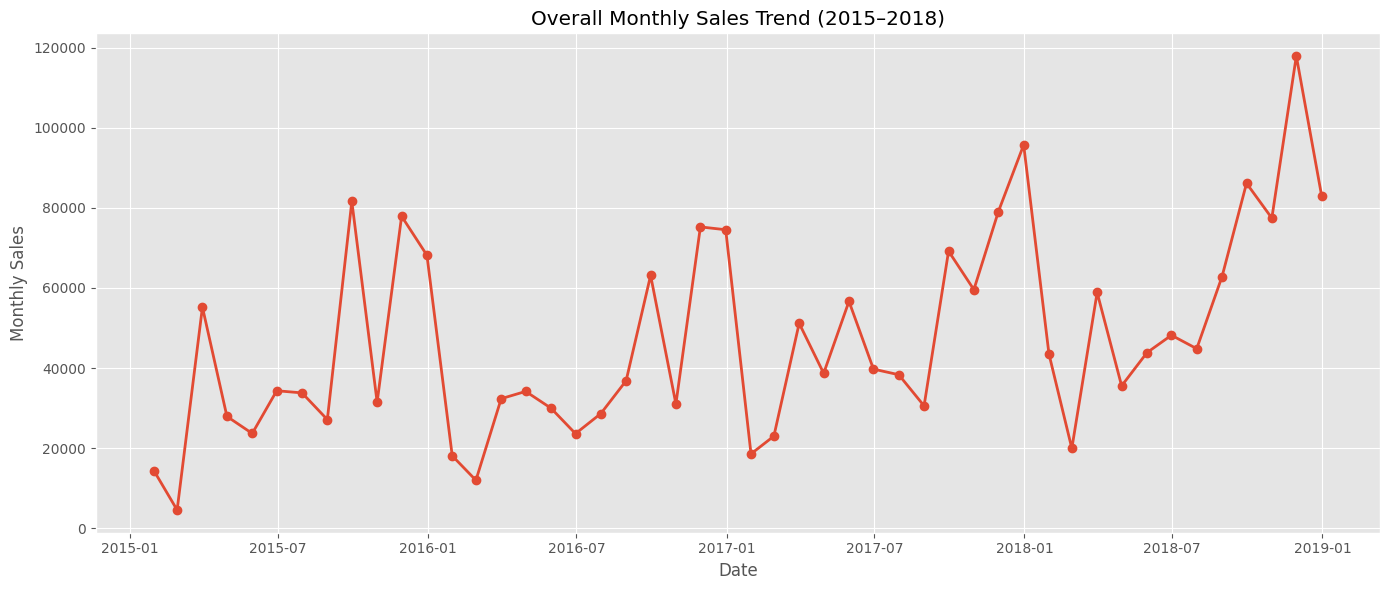

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_ts.index,
    monthly_ts.values,
    marker="o",
    linewidth=2
)

plt.title("Overall Monthly Sales Trend (2015–2018)")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/charts/monthly_sales_trend.png",
    dpi=300
)

plt.show()

## 2.3 Time Series Decomposition

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

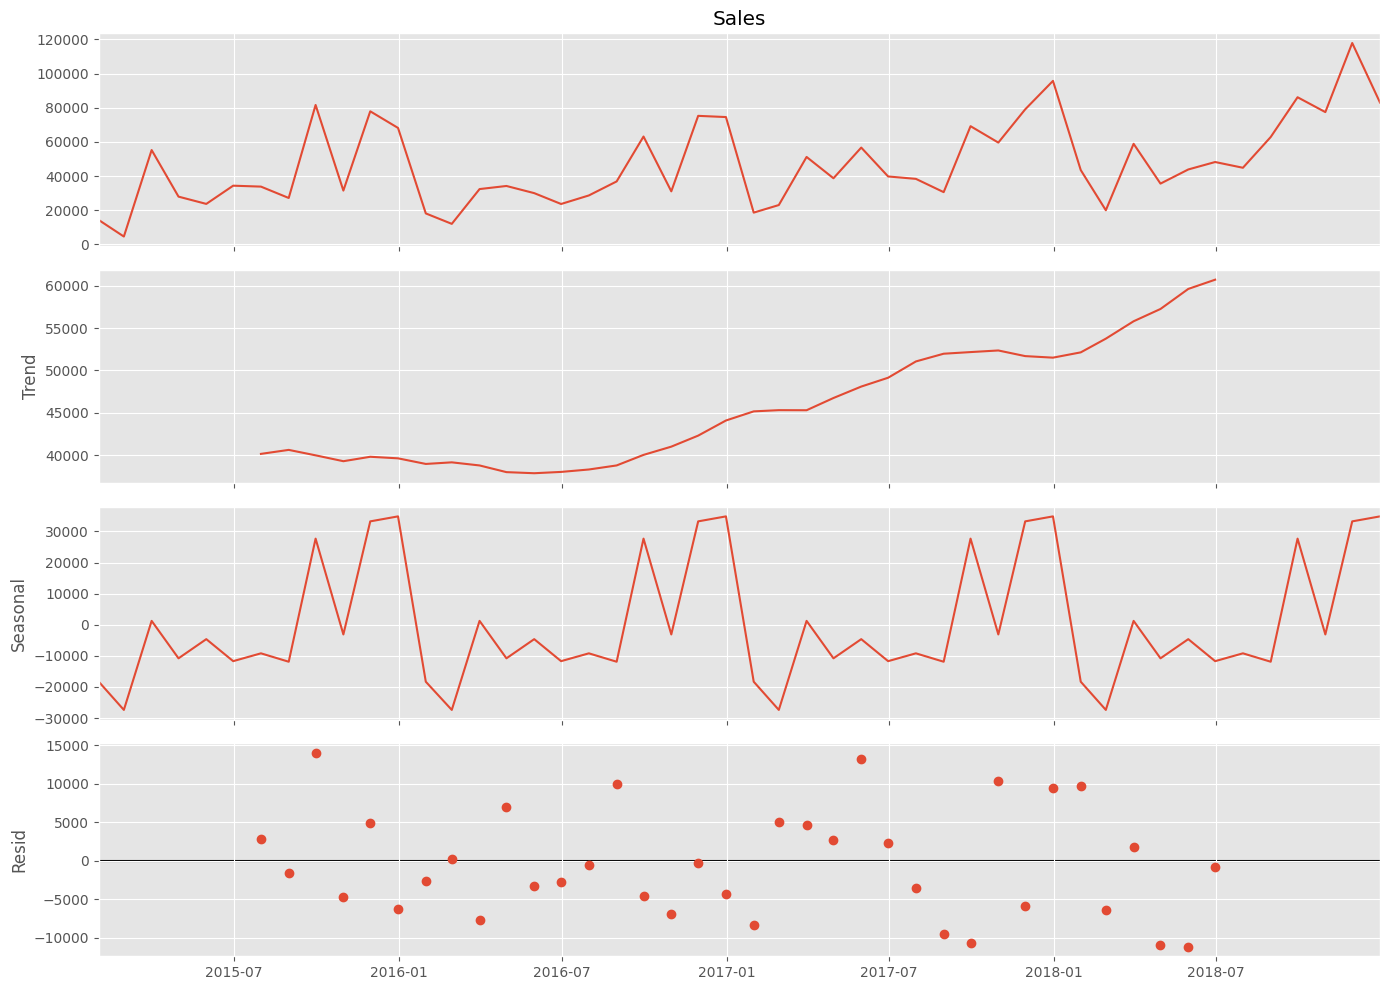

In [ ]:
decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/charts/time_series_decomposition.png",
    dpi=300
)

plt.show()

## 2.4 Stationarity Test (ADF)

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
result = adfuller(monthly_ts)

print("ADF Statistic :", result[0])
print("p-value       :", result[1])
print("Lags Used     :", result[2])
print("Observations  :", result[3])

print("\nCritical Values")

for key, value in result[4].items():
    print(f"{key}: {value}")

print()
print()
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is NOT stationary.")

ADF Statistic : -4.416136761430769
p-value       : 0.00027791039276670623
Lags Used     : 0
Observations  : 47

Critical Values
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


The time series is stationary.


#### 2.5 Differencing [not required as p value is less than 0.05]

The ADF test confirmed that the monthly sales series is already stationary (p-value < 0.05). Therefore, differencing was not applied, as it was unnecessary and could potentially remove useful information from the data.

In [ ]:
# # if p value is more than 0.05
# monthly_diff = monthly_ts.diff().dropna()
# plt.figure(figsize=(14,5))

# plt.plot(
#     monthly_diff,
#     color="darkgreen"
# )

# plt.title("First Order Differenced Series")

# plt.grid(True)

# plt.tight_layout()

# plt.savefig(
#     "/content/drive/MyDrive/charts/differenced_series.png",
#     dpi=300
# )

# plt.show()

# result2 = adfuller(monthly_diff)

# print("ADF Statistic :", result2[0])
# print("p-value :", result2[1])

# if result2[1] < 0.05:
#     print("Differenced series is stationary.")
# else:
#     print("Still non-stationary.")

## Interpretation

A stationary time series has a stable pattern over time, meaning its average level and variation remain relatively consistent. Forecasting models like SARIMA work best with stationary data because they can identify repeating patterns more reliably. If the data shows a strong upward trend or changing variability, it is transformed using differencing before model training.

# Task 3 – Sales Forecasting using 3 Different Models

In [ ]:
# Train = First 45 months
train = monthly_ts.iloc[:-3]

# Test = Last 3 months
test = monthly_ts.iloc[-3:]

print("Training Months :", len(train))
print("Testing Months  :", len(test))

display(test)

Training Months : 45
Testing Months  : 3


,Sales
Order Date,
2018-10-31,77448.1312
2018-11-30,117938.1550
2018-12-31,83030.3888


## Model 1 - SARIMA

In [ ]:
!pip install statsmodels

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

### Train SARIMA

In [ ]:
sarima = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_model = sarima.fit()

print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Sun, 12 Jul 2026   AIC                            417.362
Time:                                    17:45:09   BIC                            422.084
Sample:                                01-31-2015   HQIC                           418.161
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
ma.L1         -0.9959      0.293   

### SARIMA Parameter Selection

The SARIMA model was configured using:

- Non-seasonal Order (p, d, q): **(1, 0, 1)**
- Seasonal Order (P, D, Q, m): **(1, 1, 1, 12)**

These parameters were selected because:

- The monthly sales series was found to be **stationary** based on the Augmented Dickey-Fuller (ADF) test, therefore **d = 0**.
- The data exhibits **annual seasonality**, so a seasonal period of **12 months** was used.
- A simple (1,0,1) structure provides a good baseline while reducing the risk of overfitting given the relatively short time series (48 monthly observations).

### Forecast

In [ ]:
sarima_forecast = sarima_model.get_forecast(steps=3)

sarima_pred = sarima_forecast.predicted_mean

sarima_ci = sarima_forecast.conf_int()

display(sarima_pred)

,predicted_mean
2018-10-31,54758.511838
2018-11-30,88412.595549
2018-12-31,92558.210414


### Plot

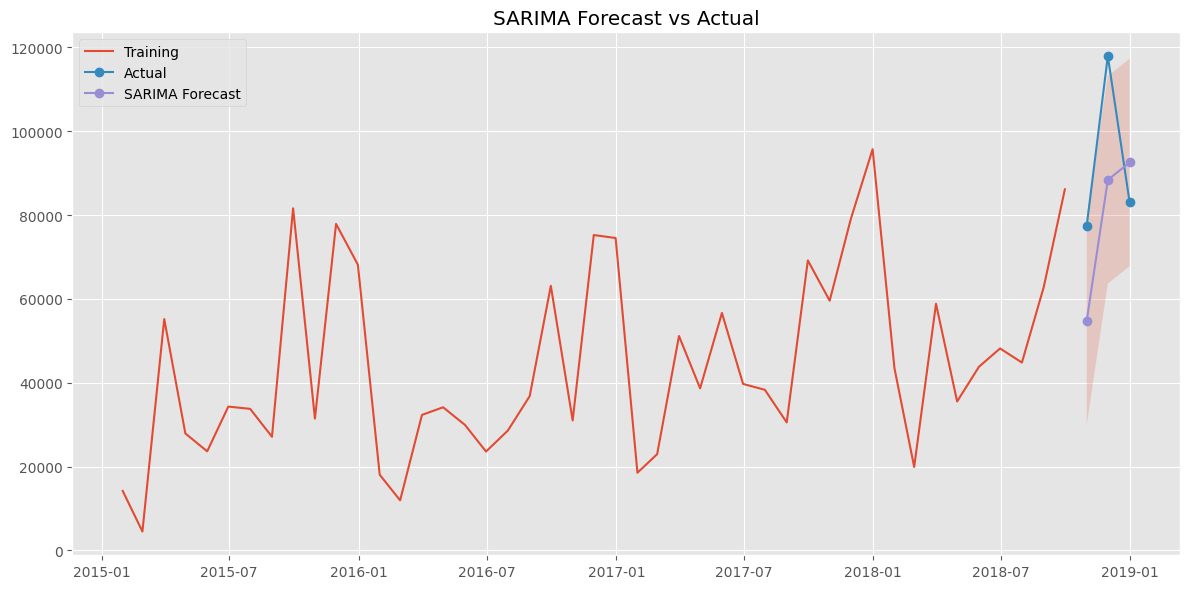

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Training")

plt.plot(test.index, test,
         marker='o',
         label="Actual")

plt.plot(test.index,
         sarima_pred,
         marker='o',
         label="SARIMA Forecast")

plt.fill_between(
    test.index,
    sarima_ci.iloc[:,0],
    sarima_ci.iloc[:,1],
    alpha=0.2
)

plt.title("SARIMA Forecast vs Actual")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/charts/sarima_forecast.png",dpi=300)

plt.show()

### Evaluation

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

sarima_mae = mean_absolute_error(test, sarima_pred)

sarima_rmse = np.sqrt(
    mean_squared_error(test, sarima_pred)
)

sarima_mape = (
    np.mean(
        np.abs(
            (test - sarima_pred)/test
        )
    )
)*100

print("MAE :", sarima_mae)
print("RMSE:", sarima_rmse)
print("MAPE:", sarima_mape)

MAE : 20581.00014223503
RMSE: 22191.26609266294
MAPE: 21.935472982348106


### SARIMA Model Performance

The SARIMA model successfully captured the overall upward trend in monthly sales and generated forecasts for the final three months of the dataset. It achieved a Mean Absolute Error (MAE) of **20,581**, a Root Mean Squared Error (RMSE) of **22,191**, and a Mean Absolute Percentage Error (MAPE) of **21.94%**.

The forecast follows the general sales pattern reasonably well, although it slightly underestimates the sharp increase observed during the peak sales period. This suggests that while SARIMA effectively models seasonality and trend, it may struggle with sudden changes in demand caused by promotional events or holiday shopping.

## Model 2 – Facebook Prophet

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

### Train Prophet

In [ ]:
prophet_train = train.reset_index()

prophet_train.columns = ["ds", "y"]

prophet_train.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)

prophet_model.fit(prophet_train)

In [ ]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="M"
)

### Forecast

In [ ]:
forecast = prophet_model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277762,38815.400052,55231.196506,54942.277762,54942.277762,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558193
44,2018-09-30,55441.608151,78352.013621,95044.191814,55441.608151,55441.608151,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953271
45,2018-10-31,55957.582886,43639.902534,60261.176055,55957.443462,55957.724208,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943812
46,2018-11-30,56456.913275,81891.127902,98451.438119,56456.425538,56457.407175,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654736
47,2018-12-31,56972.888010,81730.037276,97832.102630,56971.896661,56973.942194,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084430


In [ ]:
prophet_pred = forecast["yhat"].tail(3).values

prophet_pred

array([51318.94381151, 90325.6547358 , 90041.08443015])

### Evaluation

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

prophet_mae = mean_absolute_error(
    test,
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test,
        prophet_pred
    )
)

prophet_mape = (
    np.mean(
        np.abs(
            (test.values - prophet_pred)
            / test.values
        )
    )
)*100

print("MAE :", prophet_mae)
print("RMSE:", prophet_rmse)
print("MAPE:", prophet_mape)

MAE : 20250.794427610937
RMSE: 22318.41136551923
MAPE: 21.864628287701436


### Plot

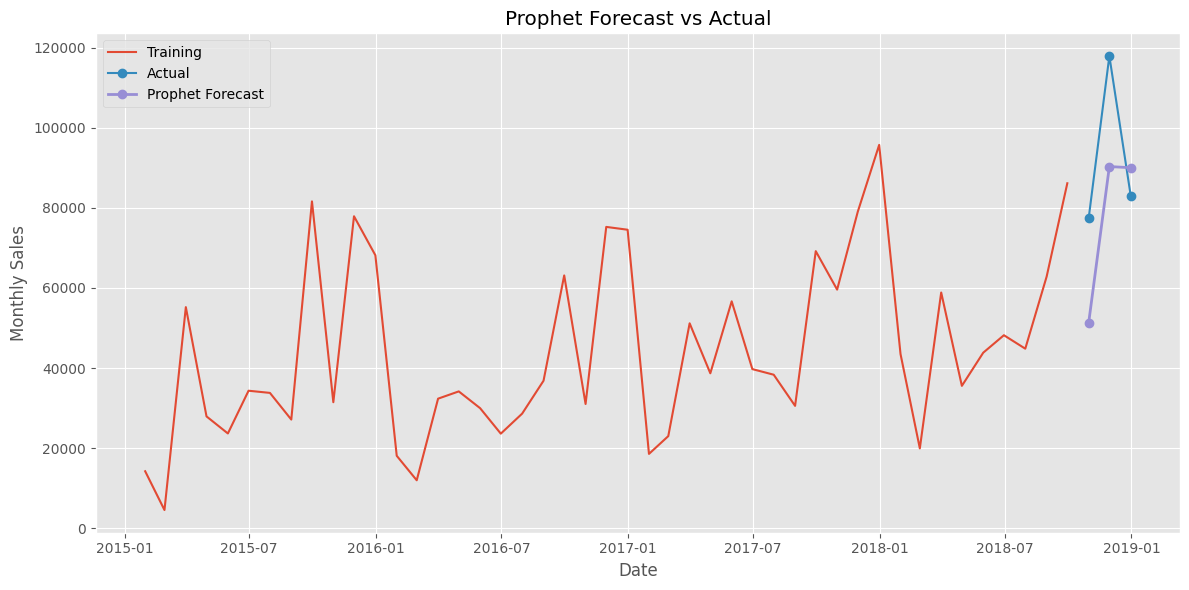

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train.values,
    label="Training"
)

plt.plot(
    test.index,
    test.values,
    marker="o",
    label="Actual"
)

plt.plot(
    test.index,
    prophet_pred,
    marker="o",
    linewidth=2,
    label="Prophet Forecast"
)

plt.title("Prophet Forecast vs Actual")

plt.xlabel("Date")
plt.ylabel("Monthly Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/charts/prophet_forecast.png",
    dpi=300
)

plt.show()

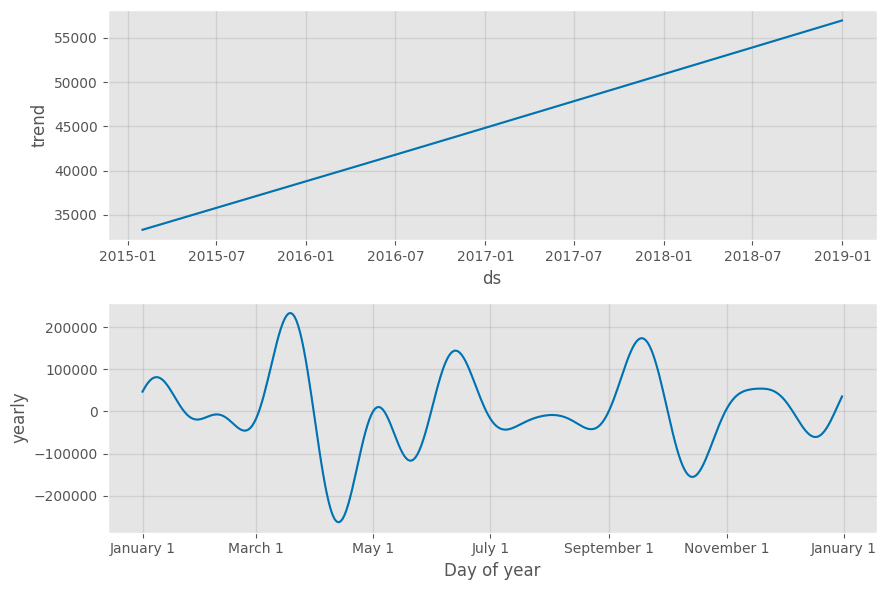

In [ ]:
fig = prophet_model.plot_components(forecast)

fig.savefig(
    "/content/drive/MyDrive/charts/prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Prophet Model

Prophet is a forecasting model developed by Meta (Facebook) that automatically captures long-term trends and recurring seasonal patterns. Since the data was aggregated to monthly sales, only yearly seasonality was enabled while weekly and daily seasonality were disabled.

This configuration aligns with the business problem because retail sales often follow annual purchasing cycles rather than weekly fluctuations when viewed at the monthly level.

### Prophet Model Performance

The Prophet model successfully learned the long-term sales trend and yearly seasonal pattern from the monthly sales data. It achieved a Mean Absolute Error (MAE) of **20,250.79**, a Root Mean Squared Error (RMSE) of **22,318.41**, and a Mean Absolute Percentage Error (MAPE) of **21.86%**.

Compared to the SARIMA model, Prophet produced a slightly lower average forecasting error, indicating a marginal improvement in predictive accuracy. This suggests that Prophet is well suited for capturing the recurring yearly sales patterns present in the retail dataset.

## Model 3 – XGBoost

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb

### Train XGBoost

In [ ]:
ts_df = monthly_ts.to_frame(name="Sales").copy()

#### Lag Features

In [ ]:
ts_df["Lag_1"] = ts_df["Sales"].shift(1)
ts_df["Lag_2"] = ts_df["Sales"].shift(2)
ts_df["Lag_3"] = ts_df["Sales"].shift(3)

#### Rolling Features

In [ ]:
ts_df["RollingMean_3"] = (
    ts_df["Sales"]
    .rolling(3)
    .mean()
)

ts_df["RollingStd_3"] = (
    ts_df["Sales"]
    .rolling(3)
    .std()
)

#### Calendar Features

In [ ]:
ts_df["Month"] = ts_df.index.month
ts_df["Quarter"] = ts_df.index.quarter
ts_df["Year"] = ts_df.index.year

# Meteorological seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 1  # Winter
    elif month in [3, 4, 5]:
        return 2  # Spring
    elif month in [6, 7, 8]:
        return 3  # Summer
    else:
        return 4  # Autumn

ts_df["Season"] = ts_df["Month"].apply(get_season)

In [ ]:
ts_df.dropna(inplace=True)

ts_df.head()

,Sales,Lag_1,Lag_2,Lag_3,RollingMean_3,RollingStd_3,Month,Quarter,Year,Season
Order Date,,,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,25368.100830,4,2,2015,2
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,17124.687284,5,2,2015,2
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,5375.385785,6,2,2015,3
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,6015.118937,7,3,2015,3
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,4012.893070,8,3,2015,3


In [ ]:
# Features and Target
X = ts_df.drop(columns="Sales")
y = ts_df["Sales"]

# Chronological Split
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 42
Testing Samples : 3


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

### Forecast

In [ ]:
xgb_pred = xgb_model.predict(X_test)

xgb_pred

array([71752.766, 87598.93 , 75994.94 ], dtype=float32)

### Evaluation

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_mape = (
    np.mean(
        np.abs(
            (y_test - xgb_pred) / y_test
        )
    )
) * 100

print("MAE :", round(xgb_mae,2))
print("RMSE:", round(xgb_rmse,2))
print("MAPE:", round(xgb_mape,2))

MAE : 14356.68
RMSE: 18279.34
MAPE: 13.85


### Plot

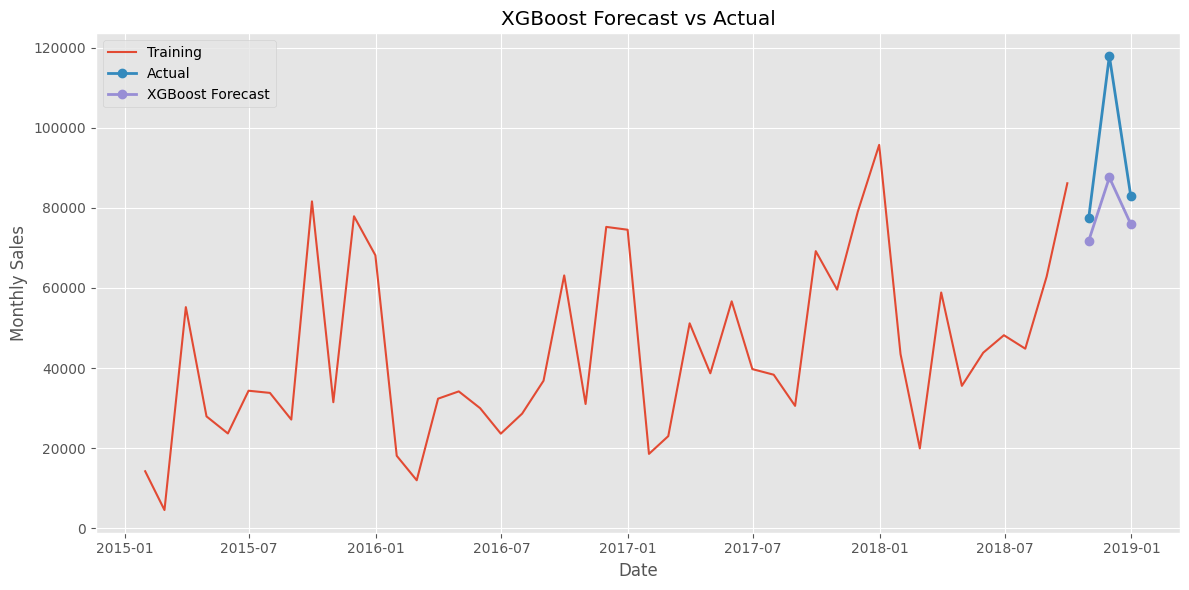

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train.values,
    label="Training"
)

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    y_test.index,
    xgb_pred,
    marker="o",
    linewidth=2,
    label="XGBoost Forecast"
)

plt.title("XGBoost Forecast vs Actual")

plt.xlabel("Date")

plt.ylabel("Monthly Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/charts/xgboost_forecast.png",
    dpi=300
)

plt.show()

### Feature Importance

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(10))

,Feature,Importance
5,Month,0.357903
8,Season,0.168401
6,Quarter,0.139785
3,RollingMean_3,0.116042
7,Year,0.069795
4,RollingStd_3,0.062051
1,Lag_2,0.033637
0,Lag_1,0.030944
2,Lag_3,0.021441


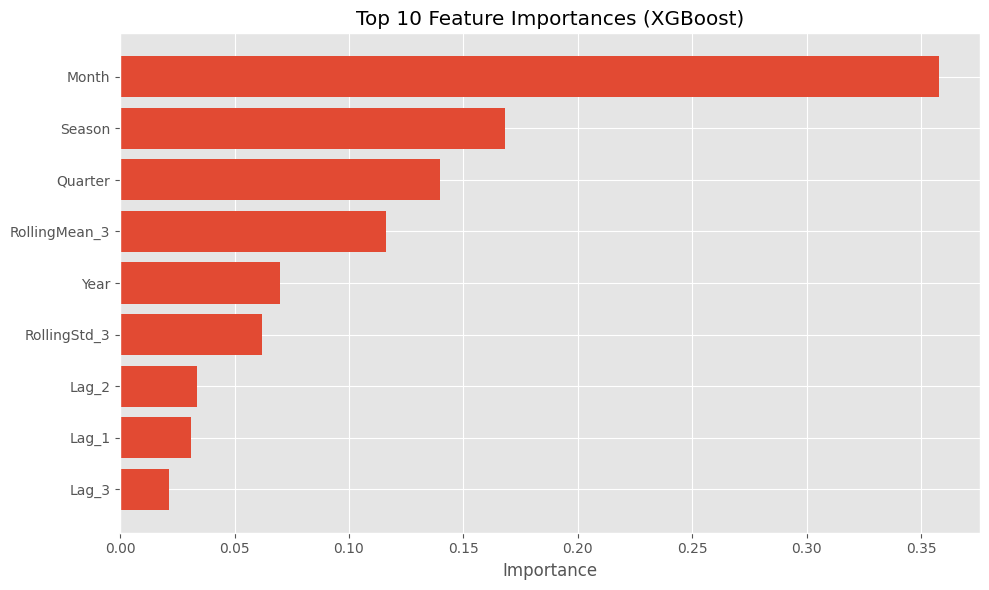

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10][::-1],
    importance["Importance"][:10][::-1]
)

plt.title("Top 10 Feature Importances (XGBoost)")

plt.xlabel("Importance")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/charts/xgb_feature_importance.png",
    dpi=300
)

plt.show()

## Model Comparison

Three different forecasting approaches were evaluated:

- **SARIMA**, a statistical time-series model.
- **Prophet**, a forecasting model developed by Meta for business time series.
- **XGBoost**, a machine learning model trained using lag features, rolling statistics, and calendar information.

The models were compared using MAE, RMSE, and MAPE on the same three-month test period. The model with the lowest forecasting errors will be selected for the remaining forecasting tasks in this project.

In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1":[
        sarima_pred.iloc[0],
        prophet_pred[0],
        xgb_pred[0]
    ],

    "Forecast Month 2":[
        sarima_pred.iloc[1],
        prophet_pred[1],
        xgb_pred[1]
    ],

    "Forecast Month 3":[
        sarima_pred.iloc[2],
        prophet_pred[2],
        xgb_pred[2]
    ]

})

comparison.round(2)

comparison["Rank"] = (
    comparison["MAPE"]
    .rank(method="dense")
)

comparison = comparison.sort_values("Rank")

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3,Rank
2,XGBoost,14356.680729,18279.344961,13.850605,71752.765625,87598.929688,75994.937500,1.0
1,Prophet,20250.794428,22318.411366,21.864628,51318.943812,90325.654736,90041.084430,2.0
0,SARIMA,20581.000142,22191.266093,21.935473,54758.511838,88412.595549,92558.210414,3.0


## Model Selection

Three forecasting approaches were evaluated using the same three-month test period.

Among them, **XGBoost achieved the best overall performance**, producing the lowest MAE, RMSE, and MAPE values. Its ability to learn nonlinear relationships using lag features, rolling statistics, and calendar-based information enabled it to capture demand patterns more accurately than the statistical forecasting models.

Based on these evaluation metrics, XGBoost was selected as the production-ready forecasting model and will be used for category-level and region-level forecasting in the remaining sections of this project.

### Feature Importance Analysis

The XGBoost model identified **Month**, **Season**, and **Quarter** as the most influential predictors of future sales. This indicates that calendar-related seasonal patterns play a greater role in forecasting demand than short-term historical sales alone.

Rolling averages also contributed significantly, suggesting that recent sales trends provide valuable forecasting information. In contrast, individual lag features had relatively lower importance, indicating that demand is influenced by broader seasonal behavior rather than simply repeating the previous month's sales.

# Task 4 – Product Category & Region Level Forecasting

## Forecast Function

In [ ]:
from xgboost import XGBRegressor

def forecast_segment(df, segment_name):

    # Monthly aggregation
    monthly = (
        df
        .set_index("Order Date")
        .resample("M")["Sales"]
        .sum()
        .to_frame()
    )

    # Lag Features
    monthly["Lag_1"] = monthly["Sales"].shift(1)
    monthly["Lag_2"] = monthly["Sales"].shift(2)
    monthly["Lag_3"] = monthly["Sales"].shift(3)

    # Rolling Features
    monthly["RollingMean_3"] = monthly["Sales"].rolling(3).mean()
    monthly["RollingStd_3"] = monthly["Sales"].rolling(3).std()

    # Calendar Features
    monthly["Month"] = monthly.index.month
    monthly["Quarter"] = monthly.index.quarter
    monthly["Year"] = monthly.index.year

    monthly["Season"] = monthly["Month"].apply(get_season)

    monthly = monthly.dropna()

    X = monthly.drop(columns="Sales")
    y = monthly["Sales"]

    X_train = X.iloc[:-3]
    X_test = X.iloc[-3:]

    y_train = y.iloc[:-3]
    y_test = y.iloc[-3:]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    return y_test.index, y_test.values, pred

## Forecast Categories

In [ ]:
furniture = sales_df[sales_df["Category"]=="Furniture"]

technology = sales_df[sales_df["Category"]=="Technology"]

office = sales_df[sales_df["Category"]=="Office Supplies"]

In [ ]:
f_dates,f_actual,f_pred = forecast_segment(furniture,"Furniture")

t_dates,t_actual,t_pred = forecast_segment(technology,"Technology")

o_dates,o_actual,o_pred = forecast_segment(office,"Office Supplies")

## Forecast Regions

In [ ]:
west = sales_df[sales_df["Region"]=="West"]

east = sales_df[sales_df["Region"]=="East"]

In [ ]:
w_dates,w_actual,w_pred = forecast_segment(west,"West")

e_dates,e_actual,e_pred = forecast_segment(east,"East")

## Comparison Plot

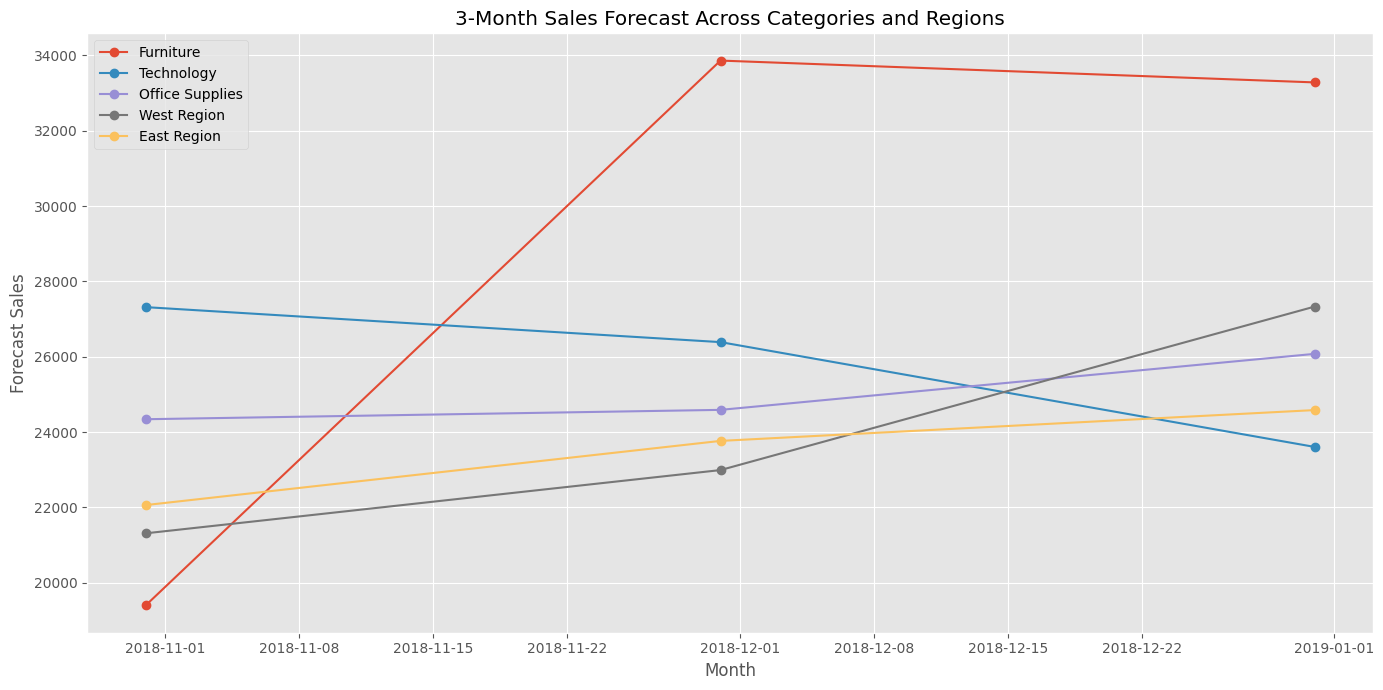

In [ ]:
plt.figure(figsize=(14,7))

plt.plot(f_dates,f_pred,marker='o',label="Furniture")

plt.plot(t_dates,t_pred,marker='o',label="Technology")

plt.plot(o_dates,o_pred,marker='o',label="Office Supplies")

plt.plot(w_dates,w_pred,marker='o',label="West Region")

plt.plot(e_dates,e_pred,marker='o',label="East Region")

plt.title("3-Month Sales Forecast Across Categories and Regions")

plt.xlabel("Month")

plt.ylabel("Forecast Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/charts/category_region_forecast.png",
    dpi=300
)

plt.show()

In [ ]:
forecast_summary = pd.DataFrame({

    "Segment":[
        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"
    ],

    "Month 1":[
        f_pred[0],
        t_pred[0],
        o_pred[0],
        w_pred[0],
        e_pred[0]
    ],

    "Month 2":[
        f_pred[1],
        t_pred[1],
        o_pred[1],
        w_pred[1],
        e_pred[1]
    ],

    "Month 3":[
        f_pred[2],
        t_pred[2],
        o_pred[2],
        w_pred[2],
        e_pred[2]
    ]

})

growth_summary = forecast_summary.copy()

growth_summary["Growth (%)"] = (
    (
        growth_summary["Month 3"] -
        growth_summary["Month 1"]
    )
    /
    growth_summary["Month 1"]
) * 100

growth_summary = growth_summary.sort_values(
    "Growth (%)",
    ascending=False
)

growth_summary.round(2)

,Segment,Month 1,Month 2,Month 3,Growth (%)
0,Furniture,19396.230469,33861.640625,33282.289062,71.589996
3,West,21311.449219,22990.820312,27330.400391,28.240000
4,East,22061.279297,23765.279297,24583.410156,11.430000
2,Office Supplies,24340.359375,24588.990234,26075.679688,7.130000
1,Technology,27316.519531,26387.650391,23605.720703,-13.580000


## Category and Region Forecasting

The best-performing forecasting model (XGBoost) was applied separately to major product categories and regions. Individual forecasts provide more actionable business insights than an overall company forecast because inventory decisions are made at the category and regional levels.

The comparison enables managers to identify which product groups and geographic markets are expected to experience the strongest demand over the next three months, allowing inventory planning and resource allocation to be optimized.

## Forecast Interpretation

The XGBoost forecasting model predicts that **Furniture** will experience the strongest growth over the next three months, showing a significant increase in projected sales after the first forecast month. **Office Supplies** demonstrates stable and consistent growth, while **Technology** begins with the highest forecast but gradually declines over the forecast horizon.

Among the geographic regions, the **West** region is expected to show the strongest increase in future sales, whereas the **East** region is projected to grow at a steadier pace. These forecasts can help business managers prioritize inventory allocation and stocking decisions for high-growth categories and regions.

# Task 5 – Anomaly Detection in Sales Data

## 5.1 Weekly Sales

In [ ]:
weekly_sales = (
    sales_df
    .set_index("Order Date")
    .resample("W")["Sales"]
    .sum()
    .to_frame()
)

weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


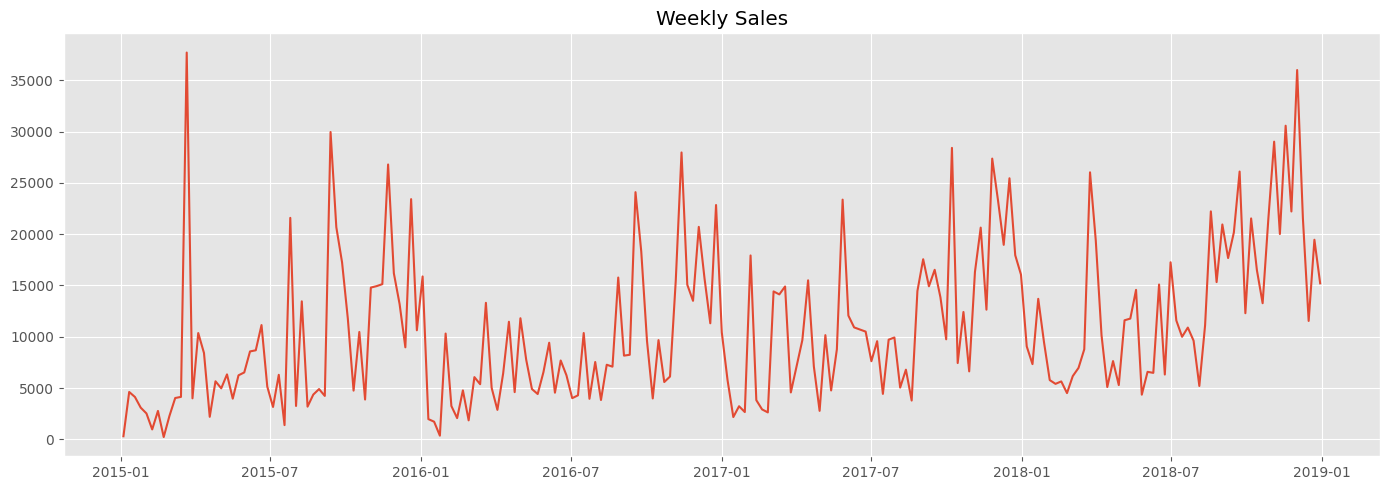

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"]
)

plt.title("Weekly Sales")

plt.grid(True)

plt.tight_layout()

plt.show()

## 5.2 Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly_IF"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

In [ ]:
weekly_sales["Anomaly_IF"].value_counts()

,count
Anomaly_IF,
1,198
-1,11


In [ ]:
if_anomalies = weekly_sales[
    weekly_sales["Anomaly_IF"] == -1
]

if_anomalies.head()

,Sales,Anomaly_IF
Order Date,,
2015-01-04,304.508,-1
2015-02-08,968.534,-1
2015-02-22,224.912,-1
2015-03-22,37703.665,-1
2015-07-19,1387.686,-1


## 5.3 Plot Isolation Forest

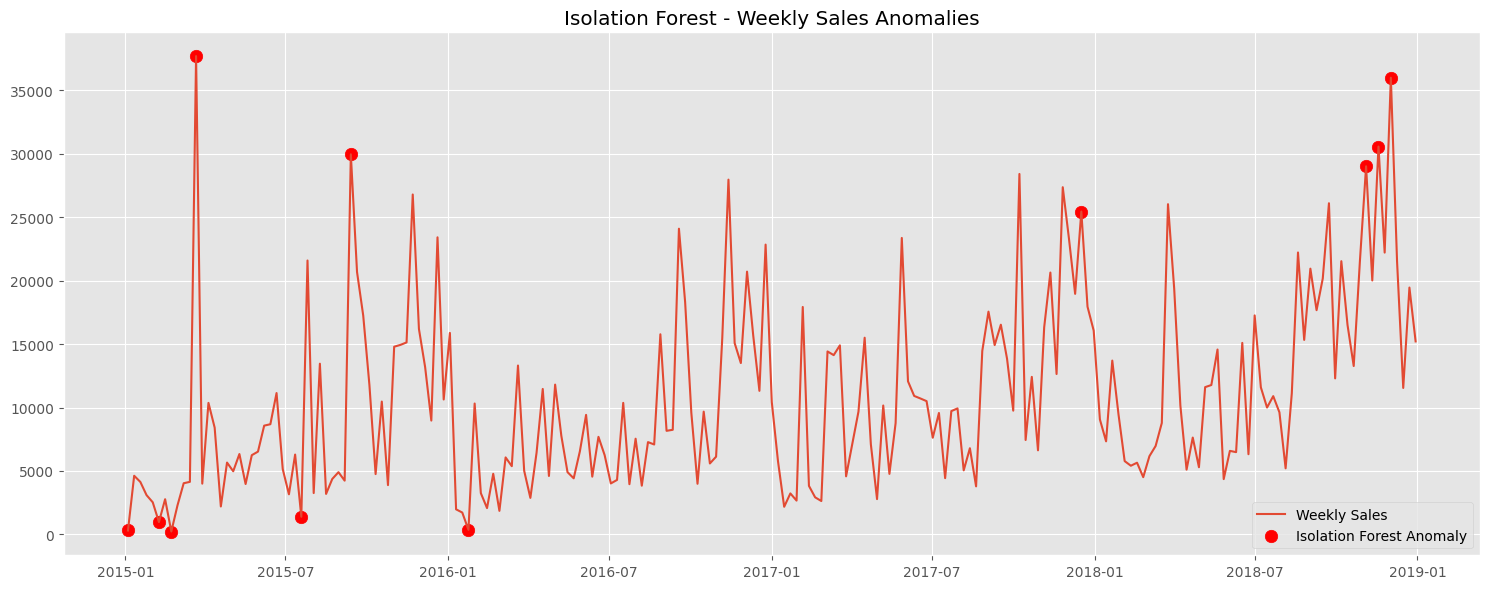

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    if_anomalies.index,
    if_anomalies["Sales"],
    color="red",
    s=80,
    label="Isolation Forest Anomaly"
)

plt.title("Isolation Forest - Weekly Sales Anomalies")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/charts/isolation_forest_anomalies.png",
    dpi=300
)

plt.show()

## 5.4 Z-Score Detection

In [ ]:
window = 8

weekly_sales["RollingMean"] = (
    weekly_sales["Sales"]
    .rolling(window)
    .mean()
)

weekly_sales["RollingStd"] = (
    weekly_sales["Sales"]
    .rolling(window)
    .std()
)

In [ ]:
weekly_sales["ZScore"] = (

    weekly_sales["Sales"]
    -
    weekly_sales["RollingMean"]

) / weekly_sales["RollingStd"]

weekly_sales["Anomaly_Z"] = (

    weekly_sales["ZScore"]
    .abs()
    >
    2
)

In [ ]:
z_anomalies = weekly_sales[
    weekly_sales["Anomaly_Z"]
]

z_anomalies.head()

,Sales,Anomaly_IF,RollingMean,RollingStd,ZScore,Anomaly_Z
Order Date,,,,,,
2015-03-22,37703.665,-1,6832.006500,12546.138409,2.460650,True
2015-07-26,21590.080,1,8245.428325,6246.129535,2.136467,True
2016-08-28,15773.478,1,7515.302525,4020.682890,2.053924,True
2016-09-18,24095.960,1,10251.475400,6524.009519,2.122082,True
2017-05-28,23367.662,1,10265.959125,6524.022836,2.008225,True


## 5.5 Plot

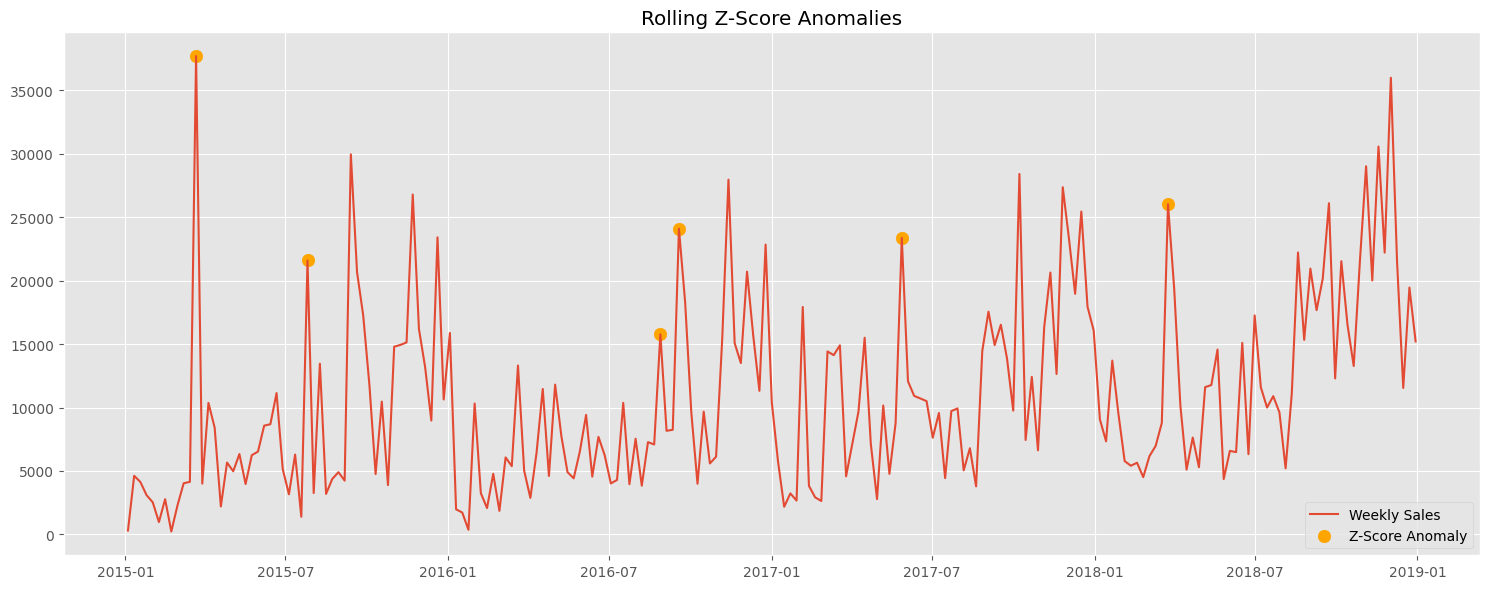

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    z_anomalies.index,
    z_anomalies["Sales"],
    color="orange",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Rolling Z-Score Anomalies")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/charts/zscore_anomalies.png",
    dpi=300
)

plt.show()

## 5.6 Comparison Table

In [ ]:
comparison_table = pd.DataFrame({

    "Method":[
        "Isolation Forest",
        "Rolling Z-Score"
    ],

    "Anomalies Detected":[
        len(if_anomalies),
        len(z_anomalies)
    ],

    "Detection Style":[
        "Machine Learning",
        "Statistical"
    ]

})

comparison_table

,Method,Anomalies Detected,Detection Style
0,Isolation Forest,11,Machine Learning
1,Rolling Z-Score,6,Statistical


In [ ]:
common = if_anomalies.index.intersection(
    z_anomalies.index
)

print("Common anomalies:", len(common))

common

Common anomalies: 1


DatetimeIndex(['2015-03-22'], dtype='datetime64[ns]', name='Order Date', freq=None)

### Anomaly Detection

Two anomaly detection approaches were applied to weekly sales.

**Isolation Forest** is a machine learning algorithm that identifies unusual observations by isolating them from the rest of the data.

**Rolling Z-Score** is a statistical technique that flags weeks where sales deviate by more than two standard deviations from the recent rolling average.

Comparing the two methods provides greater confidence in identifying genuine anomalies rather than random fluctuations. Weeks detected by both approaches are more likely to represent significant business events requiring further investigation.

In [ ]:
report = if_anomalies.copy()

median_sales = weekly_sales["Sales"].median()

report["Anomaly Type"] = report["Sales"].apply(
    lambda x:
    "High Sales Spike"
    if x > median_sales
    else
    "Unusual Sales Drop"
)

report["Possible Business Reason"] = report["Sales"].apply(
    lambda x:
    "Festival season / promotion / bulk corporate order"
    if x > median_sales
    else
    "Inventory shortage / operational disruption / reduced demand"
)

report = report.reset_index()

report[[
    "Order Date",
    "Sales",
    "Anomaly Type",
    "Possible Business Reason"
]]

,Order Date,Sales,Anomaly Type,Possible Business Reason
0,2015-01-04,304.508,Unusual Sales Drop,Inventory shortage / operational disruption / ...
1,2015-02-08,968.534,Unusual Sales Drop,Inventory shortage / operational disruption / ...
2,2015-02-22,224.912,Unusual Sales Drop,Inventory shortage / operational disruption / ...
3,2015-03-22,37703.665,High Sales Spike,Festival season / promotion / bulk corporate o...
4,2015-07-19,1387.686,Unusual Sales Drop,Inventory shortage / operational disruption / ...
5,2015-09-13,29959.137,High Sales Spike,Festival season / promotion / bulk corporate o...
6,2016-01-24,358.522,Unusual Sales Drop,Inventory shortage / operational disruption / ...
7,2017-12-17,25449.800,High Sales Spike,Festival season / promotion / bulk corporate o...
8,2018-11-04,29017.467,High Sales Spike,Festival season / promotion / bulk corporate o...
9,2018-11-18,30572.447,High Sales Spike,Festival season / promotion / bulk corporate o...


## Anomaly Detection Findings

Two different anomaly detection methods were applied to weekly sales data.

The **Isolation Forest** algorithm detected **11 anomalous weeks**, while the **Rolling Z-Score** method identified **6 anomalous weeks**. Only **one week (22 March 2015)** was detected by both methods, making it a high-confidence anomaly that likely represents a significant business event rather than random variation.

Isolation Forest identified a larger number of unusual observations because it evaluates the overall structure of the data, whereas the Rolling Z-Score method only flags weeks that deviate substantially from recent sales behavior. Using both approaches together provides a more balanced and reliable anomaly detection strategy.

# Task 6 – Product Demand Segmentation using Clustering

### Aggregate at Sub-Category Level

In [ ]:
product_df = sales_df.copy()
yearly_sales = (
    product_df
    .groupby(["Sub-Category","Year"])["Sales"]
    .sum()
    .reset_index()
)

yearly_sales.head()

,Sub-Category,Year,Sales
0,Accessories,2015,23766.396
1,Accessories,2016,40443.970
2,Accessories,2017,41735.364
3,Accessories,2018,58240.970
4,Appliances,2015,15160.715


In [ ]:
# Total Sales Volume
total_sales = (
    product_df
    .groupby("Sub-Category")["Sales"]
    .sum()
)

# Average Order Value
avg_order = (
    product_df
    .groupby("Sub-Category")["Sales"]
    .mean()
)

# Monthly Sales
monthly_sales = (

    product_df

    .groupby([
        "Sub-Category",
        pd.Grouper(
            key="Order Date",
            freq="M"
        )
    ])["Sales"]

    .sum()

    .reset_index()

)

# Volatility
volatility = (

    monthly_sales

    .groupby("Sub-Category")["Sales"]

    .std()

)

Year-over-Year Growth

In [ ]:
growth = (

    yearly_sales

    .pivot(
        index="Sub-Category",
        columns="Year",
        values="Sales"
    )

)

growth = growth.fillna(0)

growth["GrowthRate"] = (

    (
        growth.iloc[:,-1]
        -
        growth.iloc[:,0]
    )

    /

    growth.iloc[:,0]

) * 100

Feature Table

In [ ]:
cluster_data = pd.DataFrame({

    "TotalSales": total_sales,

    "GrowthRate": growth["GrowthRate"],

    "Volatility": volatility,

    "AverageOrderValue": avg_order

})

cluster_data = cluster_data.fillna(0)

cluster_data

,TotalSales,GrowthRate,Volatility,AverageOrderValue
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224
Chairs,322822.7310,20.954677,4407.232960,531.833165
Copiers,146248.0940,479.729510,5500.774391,2215.880212
Envelopes,16128.0460,-12.121345,228.218688,65.032444
Fasteners,3001.9600,30.468364,48.742229,14.027850


Scale Features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_data)

## Elbow Method

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled)

    inertia.append(model.inertia_)

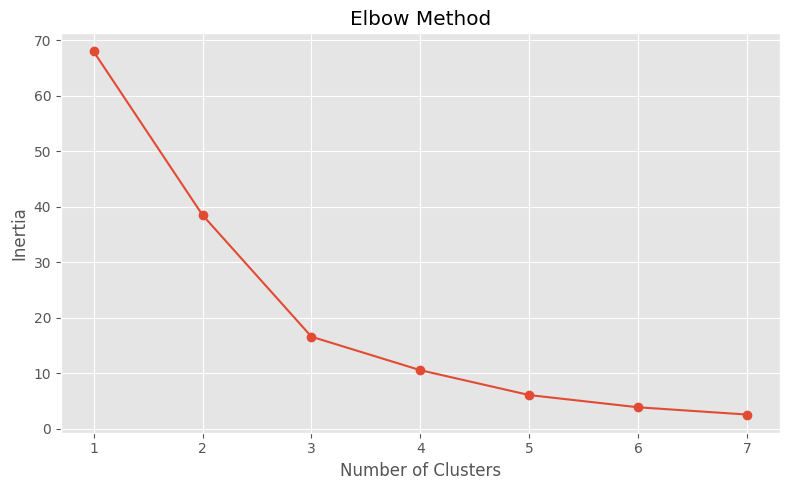

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,8),
    inertia,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/charts/elbow_method.png",
    dpi=300
)

plt.show()

## Train K-Means Model

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(scaled)

cluster_data.head()

,TotalSales,GrowthRate,Volatility,AverageOrderValue,Cluster
Sub-Category,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,1
Appliances,104618.4030,165.242912,1821.621539,227.926804,1
Art,26705.4100,49.649531,330.488343,34.019631,1
Binders,200028.7850,65.778638,3848.223648,134.067550,2
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1


## PCA for Visualization

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled)

cluster_data["PCA1"] = pca_features[:,0]
cluster_data["PCA2"] = pca_features[:,1]

### Cluster Visualization

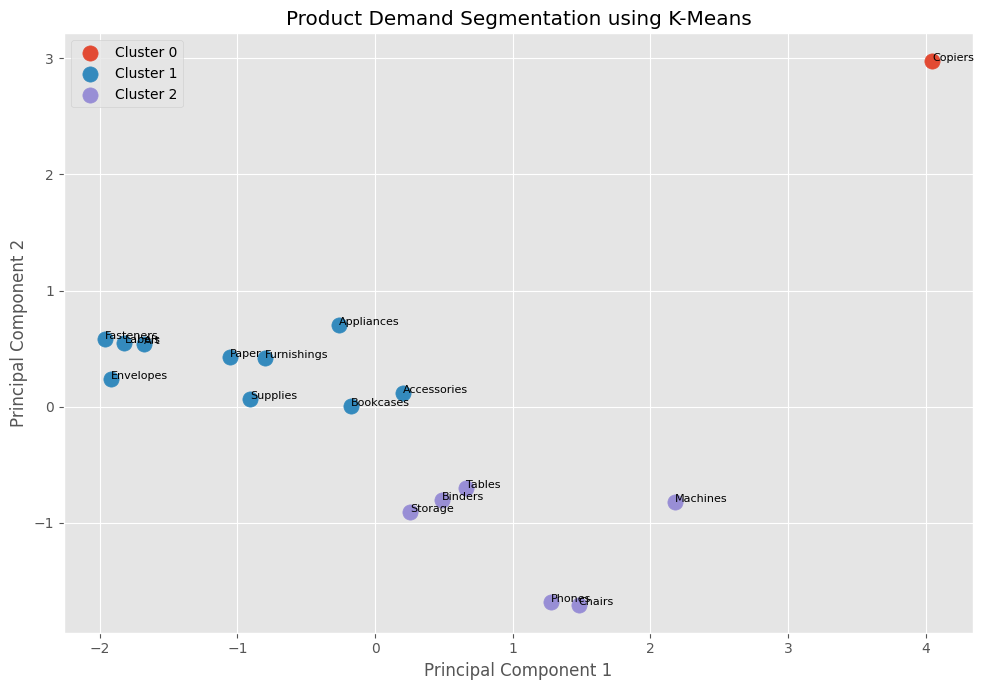

In [ ]:
plt.figure(figsize=(10,7))

for cluster in sorted(cluster_data["Cluster"].unique()):

    temp = cluster_data[
        cluster_data["Cluster"] == cluster
    ]

    plt.scatter(
        temp["PCA1"],
        temp["PCA2"],
        s=120,
        label=f"Cluster {cluster}"
    )

    for idx, row in temp.iterrows():
        plt.text(
            row["PCA1"],
            row["PCA2"],
            idx,
            fontsize=8
        )

plt.title("Product Demand Segmentation using K-Means")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/charts/product_clusters.png",
    dpi=300
)

plt.show()

## Cluster summary

In [ ]:
cluster_summary = (
    cluster_data
    .groupby("Cluster")
    .agg({
        "TotalSales":"mean",
        "GrowthRate":"mean",
        "Volatility":"mean",
        "AverageOrderValue":"mean"
    })
    .round(2)
)

cluster_summary

,TotalSales,GrowthRate,Volatility,AverageOrderValue
Cluster,,,,
0,146248.09,479.73,5500.77,2215.88
1,65326.21,67.42,1186.29,150.19
2,243671.10,27.32,3992.98,599.19


In [ ]:
cluster_mapping = {
    0: "Growing Demand",
    1: "Low Volume, Stable Demand",
    2: "High Volume, Core Products"
}

cluster_data["Demand Segment"] = (
    cluster_data["Cluster"]
    .map(cluster_mapping)
)

cluster_data.head()

,TotalSales,GrowthRate,Volatility,AverageOrderValue,Cluster,PCA1,PCA2,Demand Segment
Sub-Category,,,,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,1,0.200367,0.116729,"Low Volume, Stable Demand"
Appliances,104618.4030,165.242912,1821.621539,227.926804,1,-0.264248,0.707660,"Low Volume, Stable Demand"
Art,26705.4100,49.649531,330.488343,34.019631,1,-1.676784,0.535820,"Low Volume, Stable Demand"
Binders,200028.7850,65.778638,3848.223648,134.067550,2,0.484161,-0.805597,"High Volume, Core Products"
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1,-0.176589,0.003166,"Low Volume, Stable Demand"


In [ ]:
cluster_products = (
    cluster_data
    .reset_index()[["Sub-Category", "Demand Segment"]]
    .sort_values("Demand Segment")
)

cluster_products

,Sub-Category,Demand Segment
6,Copiers,Growing Demand
16,Tables,"High Volume, Core Products"
14,Storage,"High Volume, Core Products"
13,Phones,"High Volume, Core Products"
3,Binders,"High Volume, Core Products"
5,Chairs,"High Volume, Core Products"
11,Machines,"High Volume, Core Products"
12,Paper,"Low Volume, Stable Demand"
10,Labels,"Low Volume, Stable Demand"
0,Accessories,"Low Volume, Stable Demand"


### Inventory Strategy

In [ ]:
recommendations = pd.DataFrame({

    "Demand Segment":[
        "High Volume, Core Products",
        "Growing Demand",
        "Low Volume, Stable Demand"
    ],

    "Recommended Stocking Strategy":[
        "Maintain high inventory levels and prioritize replenishment to avoid stockouts.",
        "Gradually increase inventory while monitoring demand trends to support future growth.",
        "Keep lean inventory with periodic review to reduce storage costs and minimize excess stock."
    ]

})

recommendations

,Demand Segment,Recommended Stocking Strategy
0,"High Volume, Core Products",Maintain high inventory levels and prioritize ...
1,Growing Demand,Gradually increase inventory while monitoring ...
2,"Low Volume, Stable Demand",Keep lean inventory with periodic review to re...


In [ ]:
cluster_summary = cluster_summary.reset_index()

cluster_summary["Demand Segment"] = (
    cluster_summary["Cluster"]
    .map(cluster_mapping)
)

cluster_summary = cluster_summary[[
    "Demand Segment",
    "TotalSales",
    "GrowthRate",
    "Volatility",
    "AverageOrderValue"
]]

cluster_summary

,Demand Segment,TotalSales,GrowthRate,Volatility,AverageOrderValue
0,Growing Demand,146248.09,479.73,5500.77,2215.88
1,"Low Volume, Stable Demand",65326.21,67.42,1186.29,150.19
2,"High Volume, Core Products",243671.10,27.32,3992.98,599.19


## Product Demand Segmentation Insights

The Elbow Method indicated that **three clusters** were appropriate for grouping product sub-categories based on sales performance, growth rate, volatility, and average order value.

The clustering analysis identified three distinct demand segments:

- **High Volume, Core Products** – Products that generate the highest overall sales and should be prioritized for inventory availability.
- **Growing Demand** – Products showing exceptionally strong growth, indicating emerging demand that should be monitored closely.
- **Low Volume, Stable Demand** – Products with lower sales but relatively stable purchasing patterns, suitable for lean inventory management.

Segmenting products by demand behavior enables more effective inventory planning, improves stock availability for high-demand items, and helps reduce inventory holding costs for slower-moving products.